# SEGMENTATION
# This notebook assigns every customer to a named RFM segment
# based on their R, F, and M scores from RFM Calculation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
rfm = pd.read_csv("../Data/processed/rfm_base.csv")

In [4]:
rfm.head(5)

,customer_id,last_purchase_date,first_purchase_date,Frequency,Monetary,avg_order_value,total_items,unique_products,Recency,tenure_days,R_Score,F_Score,M_Score,RFM_Total
0,12346,2011-01-18 10:01:00,2009-12-14 08:34:00,12,77556.46,2281.072353,74285,27,326,400,2,5,5,12
1,12347,2011-12-07 15:52:00,2010-10-31 14:20:00,8,4921.53,22.169054,2967,126,2,402,5,4,5,14
2,12348,2011-09-25 13:13:00,2010-09-27 14:59:00,5,2019.40,39.596078,2714,25,75,362,3,4,4,11
3,12349,2011-11-21 09:51:00,2010-04-29 13:20:00,4,4428.69,25.306800,1624,138,19,570,5,3,5,13
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,19.670588,197,17,310,0,2,1,2,5


In [5]:

# Confirm it loaded correctly
print(f"Customers loaded: {len(rfm):,}")
print(f"Columns: {list(rfm.columns)}")
print(f"\nScore ranges:")
print(f"R_Score: {rfm['R_Score'].min()} to {rfm['R_Score'].max()}")
print(f"F_Score: {rfm['F_Score'].min()} to {rfm['F_Score'].max()}")
print(f"M_Score: {rfm['M_Score'].min()} to {rfm['M_Score'].max()}")

Customers loaded: 5,878
Columns: ['customer_id', 'last_purchase_date', 'first_purchase_date', 'Frequency', 'Monetary', 'avg_order_value', 'total_items', 'unique_products', 'Recency', 'tenure_days', 'R_Score', 'F_Score', 'M_Score', 'RFM_Total']

Score ranges:
R_Score: 1 to 5
F_Score: 1 to 5
M_Score: 1 to 5


In [6]:
rfm.head(5)

,customer_id,last_purchase_date,first_purchase_date,Frequency,Monetary,avg_order_value,total_items,unique_products,Recency,tenure_days,R_Score,F_Score,M_Score,RFM_Total
0,12346,2011-01-18 10:01:00,2009-12-14 08:34:00,12,77556.46,2281.072353,74285,27,326,400,2,5,5,12
1,12347,2011-12-07 15:52:00,2010-10-31 14:20:00,8,4921.53,22.169054,2967,126,2,402,5,4,5,14
2,12348,2011-09-25 13:13:00,2010-09-27 14:59:00,5,2019.40,39.596078,2714,25,75,362,3,4,4,11
3,12349,2011-11-21 09:51:00,2010-04-29 13:20:00,4,4428.69,25.306800,1624,138,19,570,5,3,5,13
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,19.670588,197,17,310,0,2,1,2,5


##  Assign segment labels

In [7]:
conditions = [

    # Champions: recent, frequent, high spend
    (rfm['R_Score'] >= 4) & (rfm['F_Score'] >= 4) & (rfm['M_Score'] >= 4),

    # Cannot Lose Them: high value, high frequency, but gone quiet
    # Must check BEFORE Loyal Customers — catches high-value
    # inactive customers before they fall into a lower tier
    (rfm['R_Score'] <= 2) & (rfm['F_Score'] >= 4) & (rfm['M_Score'] >= 4),

    # Loyal Customers: strong on all three, not quite Champions
    (rfm['R_Score'] >= 3) & (rfm['F_Score'] >= 3) & (rfm['M_Score'] >= 3),

    # At Risk: previously active and spending, now going quiet
    (rfm['R_Score'] <= 2) & (rfm['F_Score'] >= 3) & (rfm['M_Score'] >= 3),

    # Potential Loyalists: bought recently, moderate engagement
    (rfm['R_Score'] >= 4) & (rfm['F_Score'] >= 2) & (rfm['M_Score'] >= 2),

    # New Customers: very recent, very low frequency
    (rfm['R_Score'] >= 4) & (rfm['F_Score'] <= 1),

    # Promising: recent but low spend so far — worth nurturing
    (rfm['R_Score'] >= 3) & (rfm['F_Score'] <= 2) & (rfm['M_Score'] <= 2),

    # Needs Attention: above average recency but moderate scores
    # Catches the R=3, F=2-3, M=2-3 middle ground
    (rfm['R_Score'] == 3) & (rfm['F_Score'] >= 2) & (rfm['M_Score'] >= 2),

    # About to Sleep: low recency, low frequency, moderate spend
    (rfm['R_Score'] <= 2) & (rfm['F_Score'] <= 2) & (rfm['M_Score'] >= 2),

    # Hibernating: low across all three dimensions
    (rfm['R_Score'] <= 2) & (rfm['F_Score'] <= 2) & (rfm['M_Score'] <= 2),

]

choices = [
    'Champions',
    'Cannot Lose Them',
    'Loyal Customers',
    'At Risk',
    'Potential Loyalists',
    'New Customers',
    'Promising',
    'Needs Attention',
    'About to Sleep',
    'Hibernating',
]

rfm['Segment'] = np.select(conditions, choices, default='Others')

print("Segment distribution:")
print(rfm['Segment'].value_counts())
print(f"\nUnassigned customers remaining: {(rfm['Segment'] == 'Others').sum()}")


Segment distribution:
Segment
Champions              1297
Loyal Customers        1138
Hibernating             776
About to Sleep          747
At Risk                 393
Promising               348
Potential Loyalists     334
Others                  292
Cannot Lose Them        223
New Customers           168
Needs Attention         162
Name: count, dtype: int64

Unassigned customers remaining: 292


In [8]:
## Business Insight

# The RFM segmentation successfully classified **5,586 out of 5,878 customers (95.0%)** into meaningful business groups, 
# leaving only **292 customers (5.0%)** in the "Others" category. This indicates that the segmentation rules capture the 
# behavior of the vast majority of the customer base.

# The largest segment is **Champions**, consisting of **1,297 customers (22.1%)**, highlighting a strong core of highly engaged 
# and valuable customers who purchase frequently, spend significantly, and have bought recently.

# The business also has **1,138 Loyal Customers (19.4%)**, representing a stable source of recurring revenue that should be nurtured 
# through loyalty and cross-selling initiatives.

# On the other hand, 776 customers (13.2%) are Hibernating and 747 customers (12.7%) are About to Sleep, meaning that more than 
# one-quarter of the customer base is showing signs of disengagement and presents an opportunity for targeted reactivation campaigns.

# A total of **393 customers (6.7%) are At Risk** and **223 customers (3.8%) fall into the Cannot Lose Them segment**.
# Although these groups are relatively small, they likely represent a significant portion of historical revenue and should be 
# prioritized for retention efforts.

# Additionally, **334 customers (5.7%) are Potential Loyalists** and **168 customers (2.9%) are New Customers**, providing the business 
# with opportunities to convert recently acquired customers into long-term loyal buyers.

# Overall, the segmentation reveals a healthy base of high-value customers while also identifying several groups 
# that require targeted retention and engagement strategies to minimize future revenue loss.


## Segment summary table

In [9]:

segment_summary = rfm.groupby('Segment').agg(
    customer_count  = ('customer_id',     'count'),
    avg_recency     = ('Recency',         'mean'),
    avg_frequency   = ('Frequency',       'mean'),
    avg_monetary    = ('Monetary',        'mean'),
    total_revenue   = ('Monetary',        'sum'),
    median_monetary = ('Monetary',        'median')
).reset_index().round(2)

# Add percentage columns 
total_customers = len(rfm)
total_revenue   = rfm['Monetary'].sum()

segment_summary['customer_pct'] = (
    segment_summary['customer_count'] / total_customers * 100
).round(1)

segment_summary['revenue_pct'] = (
    segment_summary['total_revenue'] / total_revenue * 100
).round(1)

# Sort by revenue descending so Champions appear first
segment_summary = segment_summary.sort_values('total_revenue', ascending=False)

print("=" * 70)
print("SEGMENT SUMMARY TABLE")
print("=" * 70)
print(segment_summary[[
    'Segment', 'customer_count', 'customer_pct',
    'total_revenue', 'revenue_pct',
    'avg_recency', 'avg_frequency', 'avg_monetary'
]].to_string(index=False))


SEGMENT SUMMARY TABLE
            Segment  customer_count  customer_pct  total_revenue  revenue_pct  avg_recency  avg_frequency  avg_monetary
          Champions            1297          22.1    11859591.50         68.3        19.96          17.11       9143.86
    Loyal Customers            1138          19.4     2566643.71         14.8        73.38           5.95       2255.40
   Cannot Lose Them             223           3.8      982122.18          5.7       342.30           8.98       4404.14
     About to Sleep             747          12.7      533000.51          3.1       440.53           1.40        713.52
            At Risk             393           6.7      523524.67          3.0       369.27           3.72       1332.12
Potential Loyalists             334           5.7      382733.93          2.2        25.88           2.36       1145.91
             Others             292           5.0      134146.50          0.8       305.80           2.74        459.41
    Needs Attentio

In [10]:
# ## Business Insight

# The RFM segmentation reveals that the business is highly dependent on a relatively small group of high-value customers. 
# Although **Champions represent only 1,297 customers (22.1% of the customer base), they contribute £11.86 million, accounting for 68.3% of 
# total revenue**. On average, each Champion customer generates **£9,143.86** and places approximately **17 orders**, 
# making customer retention and loyalty programs for this segment a critical business priority.

# **Loyal Customers form the second most valuable segment, with 1,138 customers (19.4%) contributing £2.57 million (14.8% of total revenue).
 # Together, Champions and Loyal Customers account for **41.5% of customers but generate 83.1% of the company's total revenue**, 
# highlighting the importance of maintaining strong relationships with repeat buyers.

# # The analysis also identifies a significant revenue protection opportunity. The **Cannot Lose Them** segment consists of only **223
# customers (3.8%)**, yet they have historically generated **£982,122 (5.7% of total revenue)** despite showing signs of inactivity. 
# Similarly, **393 At Risk customers (6.7%) account for another £523,525 (3.0% of revenue)**, suggesting that targeted retention campaigns 
# could protect a meaningful portion of future sales.

# On the acquisition side, the business has **334 Potential Loyalists (5.7%)** and **168 New Customers (2.9%)**. While these groups currently 
# contribute a relatively small share of revenue, they represent the future pipeline of high-value customers and should be nurtured through 
# onboarding and engagement initiatives.

# Finally, **1,523 customers (25.9%) belong to the Hibernating and About to Sleep segments**, yet together they contribute only **3.8% of total revenue
# **. This indicates that while a large inactive customer base exists, the business impact of losing these customers is considerably lower than losing 
# high-value segments.

# Overall, the segmentation demonstrates that the company's growth strategy should prioritize three objectives:

# 1. Protect and reward Champions and Loyal Customers.
# 2. Re-engage Cannot Lose Them and At Risk customers before they churn.
# 3. Convert New Customers and Potential Loyalists into long-term repeat buyers.



## Pareto check


In [11]:
# Does the top 20% of customers drive 80% of revenue?
rfm_sorted = rfm.sort_values('Monetary', ascending=False).copy()
rfm_sorted['cumulative_revenue'] = rfm_sorted['Monetary'].cumsum()
rfm_sorted['cumulative_pct']     = rfm_sorted['cumulative_revenue'] / total_revenue * 100
rfm_sorted['customer_rank_pct']  = range(1, len(rfm_sorted) + 1)
rfm_sorted['customer_rank_pct']  = rfm_sorted['customer_rank_pct'] / len(rfm_sorted) * 100

# Find what % of revenue top 20% of customers generate
top_20_pct_revenue = rfm_sorted[rfm_sorted['customer_rank_pct'] <= 20]['Monetary'].sum()
top_20_pct = top_20_pct_revenue / total_revenue * 100

print(f"Top 20% of customers generate: {top_20_pct:.1f}% of total revenue")
print(f"This {'confirms' if top_20_pct >= 70 else 'does not confirm'} the Pareto principle")

# Where does 80% of revenue come from?
customers_for_80pct = rfm_sorted[rfm_sorted['cumulative_pct'] <= 80]
pct_customers_needed = len(customers_for_80pct) / len(rfm_sorted) * 100
print(f"\n80% of revenue comes from top {pct_customers_needed:.1f}% of customers")


Top 20% of customers generate: 77.2% of total revenue
This confirms the Pareto principle

80% of revenue comes from top 23.0% of customers


In [12]:
# ## Business Insight

# The analysis confirms the Pareto Principle, with the top 20% of customers generating approximately 77.2% of total revenue. Conversely, 
# nearly 80% of the company's revenue is produced by only 23% of customers, highlighting a significant concentration of business value 
# among a relatively small group of high-spending customers. This suggests that retaining these customers should be a major strategic 
# priority, as losing even a small portion of them could have a disproportionate impact on overall revenue.

## Visualisations

### Customer count by segment
### Revenue by segment
### Revenue share donut

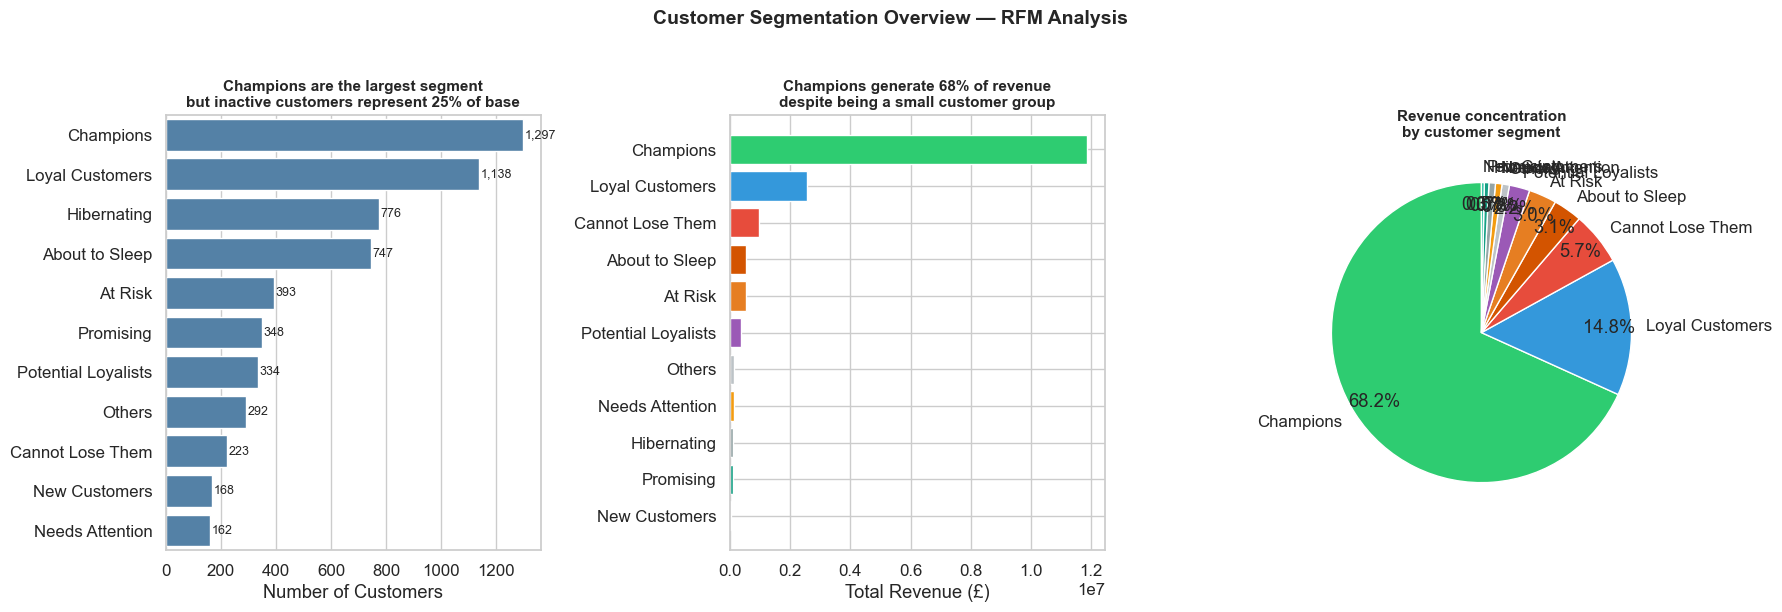

In [13]:
# Set clean style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Chart 1: Customer count by segment ──────────────────────────────────

seg_order = segment_summary.sort_values(
    'customer_count', ascending=False)['Segment'].tolist()

sns.barplot(
    data=segment_summary,
    x='customer_count',
    y='Segment',
    order=seg_order,
    ax=axes[0],
    color='steelblue'

)


axes[0].set_title(
    'Champions are the largest segment\nbut inactive customers represent 25% of base',
    fontsize=11, fontweight='bold'
)

axes[0].set_xlabel('Number of Customers')
axes[0].set_ylabel('')

# Add count labels
for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width()):,}',
        va='center', fontsize=9
    )

# ── Chart 2: Revenue by segment ─────────────────────────────────────────
rev_order = segment_summary.sort_values(
    'total_revenue', ascending=False)['Segment'].tolist()

colors = {
    'Champions':          '#2ecc71',
    'Cannot Lose Them':   '#e74c3c',
    'Loyal Customers':    '#3498db',
    'At Risk':            '#e67e22',
    'Potential Loyalists':'#9b59b6',
    'New Customers':      '#1abc9c',
    'Promising':          '#16a085',
    'Needs Attention':    '#f39c12',
    'About to Sleep':     '#d35400',
    'Hibernating':        '#95a5a6',
    'Others':             '#bdc3c7'
}

bar_colors = [colors.get(s, '#95a5a6') for s in rev_order]

rev_data = segment_summary.sort_values('total_revenue', ascending=False)
axes[1].barh(rev_data['Segment'], rev_data['total_revenue'],
             color=[colors.get(s, '#95a5a6') for s in rev_data['Segment']])
axes[1].set_title(
    f'Champions generate {segment_summary[segment_summary["Segment"]=="Champions"]["revenue_pct"].values[0]:.0f}% of revenue\ndespite being a small customer group',
    fontsize=11, fontweight='bold'
)
axes[1].set_xlabel('Total Revenue (£)')
axes[1].set_ylabel('')
axes[1].invert_yaxis()

# ── Chart 3: Revenue share donut ─────────────────────────────────────────
wedge_colors = [colors.get(s, '#95a5a6') for s in segment_summary['Segment']]
axes[2].pie(
    segment_summary['revenue_pct'],
    labels=segment_summary['Segment'],
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)
axes[2].set_title(
    'Revenue concentration\nby customer segment',
    fontsize=11, fontweight='bold'
)

plt.suptitle(
    'Customer Segmentation Overview — RFM Analysis',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

In [14]:
# The RFM segmentation reveals that although Champions account for only 1,297 customers (22.1% of the customer base),
# they generate approximately £11.86 million, representing 68.3% of total revenue. Loyal Customers contribute an additional 14.8% of revenue,
# while inactive segments such as Hibernating and About to Sleep together account for over 25% of customers but contribute less than 4% of total revenue.
# This suggests that the business should prioritize retaining high-value customers
# while implementing targeted re-engagement campaigns for inactive but potentially recoverable segments.

## Save and export

In [15]:
# Save segmented customer table
rfm.to_csv('rfm_segments.csv', index=False)

# Save segment summary separately — used in Power BI directly
segment_summary.to_csv('segment_summary.csv', index=False)

print("Files saved:")
print("  data/processed/rfm_segments.csv      — all customers with segments")
print("  data/processed/segment_summary.csv   — segment-level summary table")
print(f"\nFinal output: {len(rfm):,} customers across {rfm['Segment'].nunique()} segments")

Files saved:
  data/processed/rfm_segments.csv      — all customers with segments
  data/processed/segment_summary.csv   — segment-level summary table

Final output: 5,878 customers across 11 segments


## Recommendations

In [16]:
# # Business Recommendations by Priority Segment

# ## Priority 1 — CANNOT LOSE THEM (Highest Priority)

# **223 customers — £982,122 historical revenue — average customer value £4,404**
# These customers were once among the company's most valuable customers, demonstrating both high purchase frequency and high spending levels
# However, they have recently become inactive, making them the segment with the highest potential revenue risk.
# Rather than relying solely on automated marketing emails, these customers should receive personalized outreach from an account manager or 
# customer success representative. Exclusive loyalty rewards or limited-time VIP benefits are likely to be more effective than generic discounts.

# **Recommended Action:** Personal outreach within 14 days, supported by a 20% loyalty credit valid for 60 days.

# **Potential Business Impact:** Assuming a 40% recovery rate, approximately **89 customers** could be retained, protecting nearly **£393,000 in revenue**.

# ---

# ## Priority 2 — AT RISK

# **393 customers — £523,525 historical revenue — average customer value £1,332**

# These customers were previously engaged with the business but are showing early signs of churn. They still represent a meaningful revenue opportunity 
# and can often be recovered through targeted marketing efforts before becoming fully inactive.
# A personalized win-back campaign referencing their previous purchases, combined with a limited-time incentive, should be the first line of action.

# **Recommended Action:** Automated two-email win-back sequence over 14 days with a 15% returning customer offer.
# **Potential Business Impact:** Assuming a 30% response rate, approximately **118 customers** could return, recovering an estimated **£157,000 in revenue** while delivering a strong return on marketing investment.

# ---

# ## Priority 3 — CHAMPIONS (Protect and Reward)

# **1,297 customers — £11.86 million historical revenue — 68.3% of total business revenue**

# Although Champions represent only **22.1% of the customer base**, they generate more than two-thirds of the company's total revenue. Losing even a small percentage of these customers would have a disproportionate impact on business performance.

# Price discounts should generally be avoided for this group, as they already purchase at full value. Instead, the focus should be on recognition, exclusivity, and strengthening the customer relationship.

# **Recommended Action:** Launch a VIP loyalty programme offering early product access, exclusive events, and personalized appreciation communications.

# **Business Goal:** Reduce Champion churn and protect the company's most valuable revenue stream.

# ---

# ## Priority 4 — POTENTIAL LOYALISTS (Growth Opportunity)

# **334 customers — £382,734 historical revenue — average customer value £1,146**

# These customers have already demonstrated positive buying behaviour through recent purchases and moderate engagement but have not yet developed long-term loyalty.

# The next few weeks are critical in shaping their future relationship with the business. A structured onboarding and engagement programme can help convert these customers into Loyal Customers.

# **Recommended Action:** Three-email nurture sequence over 45 days featuring product recommendations, loyalty programme invitations, and customer success stories.

# **Business Goal:** Convert approximately 25% of this segment into Loyal Customers, strengthening the future revenue base of the business.
